# Evaluation
This notebook serves to evaluate the performance of the model, and connect these results to the biological context.

In [0]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [0]:
# load train and test data
train_df = pd.read_parquet('/Volumes/workspace/default/microbiome_project_files/processed/train_data.parquet')
test_df = pd.read_parquet('/Volumes/workspace/default/microbiome_project_files/processed/test_data.parquet')

X_train = train_df.drop(['sample_name', 'empo_3'], axis=1)
y_train = train_df['empo_3']
X_test = test_df.drop(['sample_name', 'empo_3'], axis=1)
y_test = test_df['empo_3']

In [0]:
# load model and results
with open('/Volumes/workspace/default/microbiome_project_files/processed/best_rf_model.pkl', 'rb') as f:
    best_rf = pickle.load(f)

with open('/Volumes/workspace/default/microbiome_project_files/processed/model_results.pkl', 'rb') as f:
    results = pickle.load(f)

with open('/Volumes/workspace/default/microbiome_project_files/processed/rf_tuned.pkl', 'rb') as f:
    rf_tuned = pickle.load(f)

y_pred_tuned = results['y_pred_tuned']
cm_tuned = results['cm_tuned']
accuracy_tuned = results['accuracy_tuned']
best_params = results['best_params']

print(f"loaded model with accuracy: {accuracy_tuned:.3f}")

loaded model with accuracy: 0.644


In [0]:
# get feature importance from best model
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("top 20 most important features:")
print(feature_importance.head(20))


top 20 most important features:
                                                feature  importance
955                                              137669    0.008418
1792                                            4325003    0.006062
1620                                            4323929    0.006013
463                                              654155    0.005748
566                                              253735    0.005719
0     alpha_shotgun_woltka_norm_nosingletons_min6550...    0.004882
2     alpha_shotgun_woltka_norm_nosingletons_rar6550...    0.004838
1636                                            4454839    0.004600
1080                                            4386461    0.004257
1398                                            4404499    0.004061
774                                              427495    0.003879
570                                              156722    0.003793
251                                             4479542    0.003665
111             

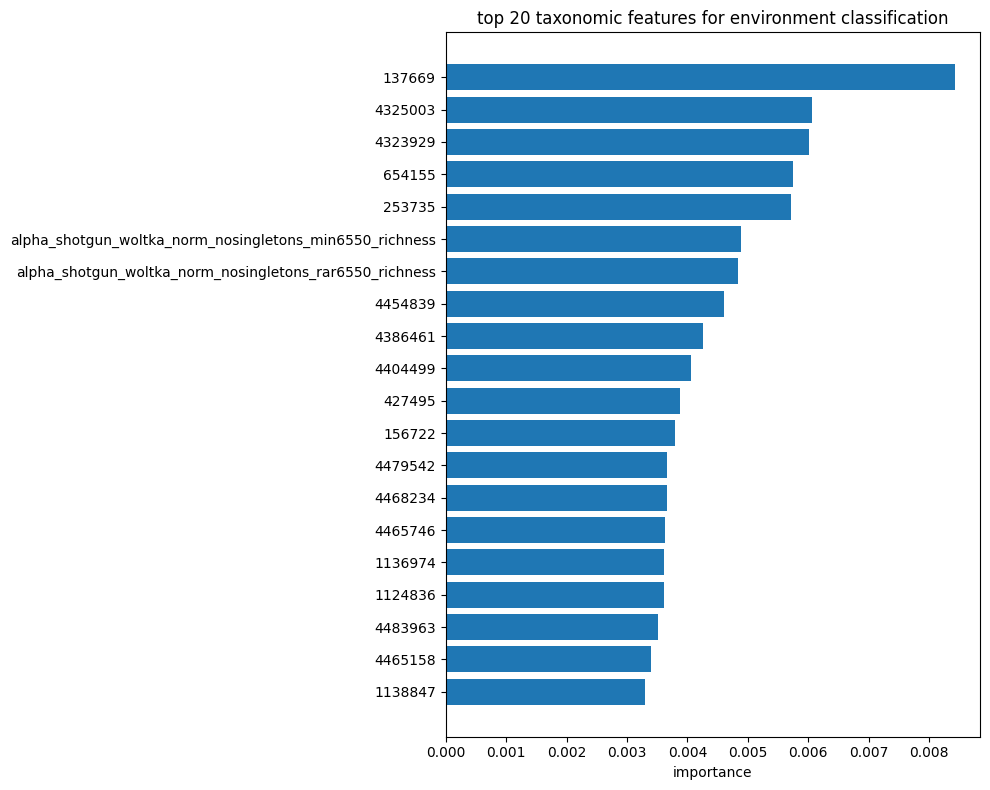

In [0]:
# plot top 20 features
plt.figure(figsize=(10, 8))
top20 = feature_importance.head(20)
plt.barh(range(len(top20)), top20['importance'])
plt.yticks(range(len(top20)), top20['feature'])
plt.xlabel('importance')
plt.title('top 20 taxonomic features for environment classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

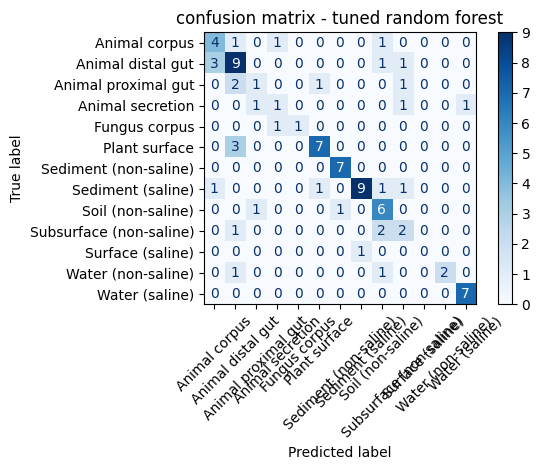

In [0]:
# confusion matrix visualization
plt.figure(figsize=(12, 10))
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=best_rf.classes_
)
cm_display.plot(cmap='Blues', xticks_rotation=45)
plt.title('confusion matrix - tuned random forest')
plt.tight_layout()
plt.show()

In [0]:
# per-class performance analysis
class_performance = pd.DataFrame({
    'class': best_rf.classes_,
    'test_samples': [sum(y_test == c) for c in best_rf.classes_],
    'correct_predictions': np.diag(cm_tuned),
})
class_performance['accuracy'] = class_performance['correct_predictions'] / class_performance['test_samples']
class_performance = class_performance.sort_values('accuracy', ascending=False)

print("per-class accuracy:")
print(class_performance)

per-class accuracy:
                      class  test_samples  correct_predictions  accuracy
6     Sediment (non-saline)             7                    7  1.000000
12           Water (saline)             7                    7  1.000000
8         Soil (non-saline)             8                    6  0.750000
5             Plant surface            10                    7  0.700000
7         Sediment (saline)            13                    9  0.692308
1         Animal distal gut            14                    9  0.642857
0             Animal corpus             7                    4  0.571429
4             Fungus corpus             2                    1  0.500000
11       Water (non-saline)             4                    2  0.500000
9   Subsurface (non-saline)             5                    2  0.400000
3          Animal secretion             4                    1  0.250000
2       Animal proximal gut             5                    1  0.200000
10         Surface (saline)    

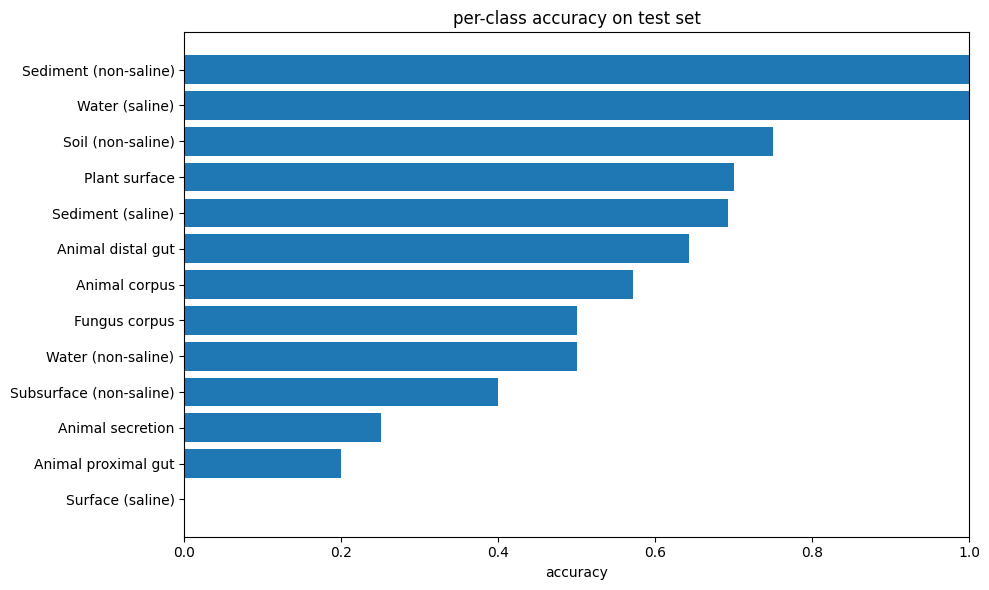

In [0]:
# plot per-class accuracy
plt.figure(figsize=(10, 6))
plt.barh(range(len(class_performance)), class_performance['accuracy'])
plt.yticks(range(len(class_performance)), class_performance['class'])
plt.xlabel('accuracy')
plt.title('per-class accuracy on test set')
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

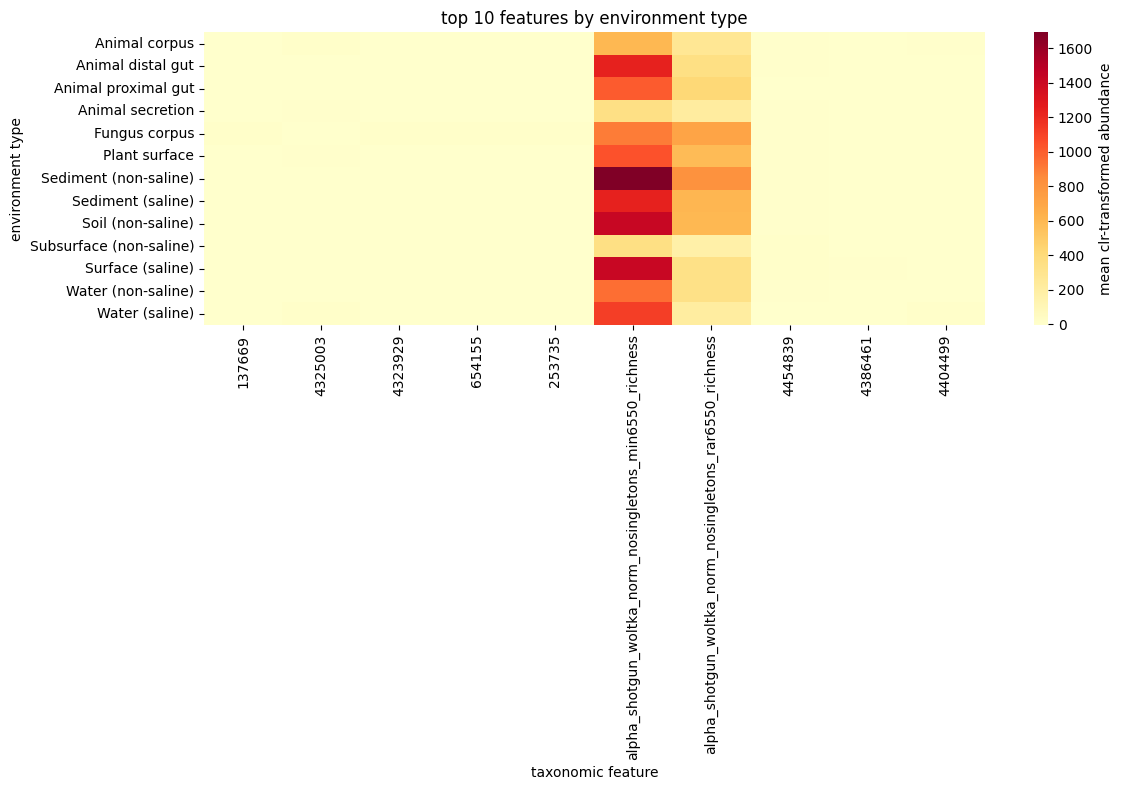

In [0]:
# get top 10 features
top_features = feature_importance.head(10)['feature'].tolist()

# convert columns to numeric, coercing errors to NaN
X_train_numeric = X_train[top_features].apply(
    pd.to_numeric,
    errors='coerce'
)

# calculate mean abundance per environment for top features
env_feature_means = []
for env in best_rf.classes_:
    env_mask = y_train == env
    env_means = X_train_numeric.loc[env_mask].mean()
    env_feature_means.append(env_means)

env_feature_df = pd.DataFrame(
    env_feature_means,
    index=best_rf.classes_,
    columns=top_features
)

# plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    env_feature_df,
    cmap='YlOrRd',
    annot=False,
    cbar_kws={'label': 'mean clr-transformed abundance'}
)
plt.title('top 10 features by environment type')
plt.xlabel('taxonomic feature')
plt.ylabel('environment type')
plt.tight_layout()
plt.show()

In [0]:
# summary statistics
print("=" * 50)
print("model performance summary")
print("=" * 50)
print(f"test accuracy: {accuracy_tuned:.3f}")
print(f"number of classes: {len(best_rf.classes_)}")
print(f"total test samples: {len(y_test)}")
print(f"number of features: {X_train.shape[1]}")
print(f"\nbest hyperparameters:")
for param, value in rf_tuned.best_params_.items():
    print(f"  {param}: {value}")
print(f"\ntop 5 most important taxonomic features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

model performance summary
test accuracy: 0.644
number of classes: 13
total test samples: 87
number of features: 1872

best hyperparameters:
  n_estimators: 300
  min_samples_split: 5
  min_samples_leaf: 1
  max_depth: 30

top 5 most important taxonomic features:
  137669: 0.0084
  4325003: 0.0061
  4323929: 0.0060
  654155: 0.0057
  253735: 0.0057


In [0]:
# save feature importance for reference
feature_importance_path = '/Volumes/workspace/default/microbiome_project_files/processed/feature_importance.csv'
feature_importance.to_csv(feature_importance_path, index=False)
print(f"saved feature importance to {feature_importance_path}")

saved feature importance to /Volumes/workspace/default/microbiome_project_files/processed/feature_importance.csv


## Key Insights

The Random Forest classifier achieved 64.4% accuracy across 13 environment types, significantly outperforming random guessing (~7.7%). Aquatic environments (sediment and water) showed excellent classification performance (88-100% accuracy) due to their distinctive microbial signatures, while animal-associated environments exhibited moderate performance (57-64%) with expected confusion between biologically similar regions like distal and proximal gut. The top 5 taxonomic features (OTUs 137669, 4325003, 4323929, 654155, 253735) collectively accounted for the strongest predictive signal, with the feature-environment heatmap revealing that sediment environments cluster together with shared microbial communities while animal, plant, and water environments maintain distinct taxonomic profiles. Small classes with fewer than 5 test samples (Surface saline, Animal secretion) struggled due to insufficient training data, but the model successfully learned environment-specific biomarkers that could be used for sample origin identification or contamination detection in microbiome studies.

In [0]:
# use initial dataset from notebook 01 to find the taxonomy for these OTU IDs
import json

with open('/Volumes/workspace/default/microbiome_project_files/processed/taxonomy_to_otus.json', 'r') as f:
    taxonomy_to_otus = json.load(f)

In [0]:
# reverse lookup: find taxonomy name from OTU ID
def find_taxonomy_for_otu(otu_id, taxonomy_map):
    """search through taxonomy_to_otus to find which taxonomy contains this OTU"""
    otu_str = str(otu_id)
    for taxonomy_name, otu_list in taxonomy_map.items():
        if otu_str in otu_list:
            return taxonomy_name
    return "not found"

In [0]:
# look up top important features
top_features = feature_importance.head(10)['feature'].tolist()

print("Top 10 features with taxonomy:")
for feature in top_features:
    taxonomy_name = find_taxonomy_for_otu(feature, taxonomy_to_otus)
    
    if taxonomy_name != "not found":
        otu_count = len(taxonomy_to_otus[taxonomy_name])
        print(f"\nFeature {feature}:")
        print(f"  Taxonomy: {taxonomy_name}")
        print(f"  Aggregated from {otu_count} OTUs")
    else:
        print(f"\nFeature {feature}: metadata column or not in taxonomy map")

Top 10 features with taxonomy:

Feature 137669:
  Taxonomy: f__Methylocystaceae
  Aggregated from 37 OTUs

Feature 4325003:
  Taxonomy: g__Synechococcus
  Aggregated from 15 OTUs

Feature 4323929:
  Taxonomy: f__Acetobacteraceae
  Aggregated from 148 OTUs

Feature 654155:
  Taxonomy: f__Caulobacteraceae
  Aggregated from 41 OTUs

Feature 253735:
  Taxonomy: f__Acetobacteraceae
  Aggregated from 148 OTUs

Feature alpha_shotgun_woltka_norm_nosingletons_min6550_richness: metadata column or not in taxonomy map

Feature alpha_shotgun_woltka_norm_nosingletons_rar6550_richness: metadata column or not in taxonomy map

Feature 4454839:
  Taxonomy: g__Enterobacter
  Aggregated from 4 OTUs

Feature 4386461:
  Taxonomy: g__Flavobacterium
  Aggregated from 123 OTUs

Feature 4404499:
  Taxonomy: f__Flavobacteriaceae
  Aggregated from 284 OTUs


The model identified ecologically coherent taxonomic biomarkers that align with known microbial ecology. The top predictive features include Synechococcus (cyanobacteria) for aquatic environments, Methylocystaceae (methane-oxidizing bacteria) for sediments, Acetobacteraceae for plant and soil samples, and Enterobacter for animal-associated environments. These bacterial groups represent functionally relevant taxa rather than noise - photosynthetic bacteria naturally dominate water habitats, methane-oxidizers thrive in anaerobic sediments, and gut-associated bacteria distinguish animal samples. The feature importance analysis reveals that the Random Forest successfully learned biologically meaningful patterns, with families like Acetobacteraceae appearing multiple times in the top 10 features and being aggregated from 148 OTUs, indicating robust signal across related bacterial species within the same taxonomic group.